In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv('Mall_Customers.csv')
x=dataset.iloc[:,[3,4]].values

x

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [18]:
n_samples=100000
range_n_clusters = range(2, 10)
silhouette_avg_scores = []

from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

for n_clusters in range_n_clusters:
    # Initialize the SpectralClustering model
    clusterer = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', n_neighbors=int(np.log(n_samples)))
    cluster_labels = clusterer.fit_predict(x)
    
    # Calculate the average silhouette score
    silhouette_avg = silhouette_score(x, cluster_labels)
    silhouette_avg_scores.append(silhouette_avg)

# 3. Plot the Silhouette scores (Elbow method visualization)
# The optimal k is the one with the highest silhouette score
optimal_k = range_n_clusters[np.argmax(silhouette_avg_scores)]
print(f"Optimal number of clusters determined by Silhouette Score: {optimal_k}")

#from sklearn.cluster import SpectralClustering
sc=SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors')
y_pred=sc.fit_predict(x)
y_pred

Optimal number of clusters determined by Silhouette Score: 5


/Users/Max/opt/anaconda3/envs/aiml/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:236: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"


array([0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 1,
       0, 4, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 2, 3, 1, 3, 2, 3, 2, 3,
       1, 3, 2, 3, 2, 3, 2, 3, 2, 3, 1, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3], dtype=int32)

In [19]:
supervised=dataset
supervised['cluster_group']=y_pred
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster_group
0,1,Male,19,15,39,0
1,2,Male,21,15,81,4
2,3,Female,20,16,6,0
3,4,Female,23,16,77,4
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,3
196,197,Female,45,126,28,2
197,198,Male,32,126,74,3
198,199,Male,32,137,18,2


In [29]:
supervised.to_csv('cluster_spectral.csv',index=False)
supervised.columns[3:6]


Index(['Annual Income (k$)', 'Spending Score (1-100)', 'cluster_group'], dtype='object')

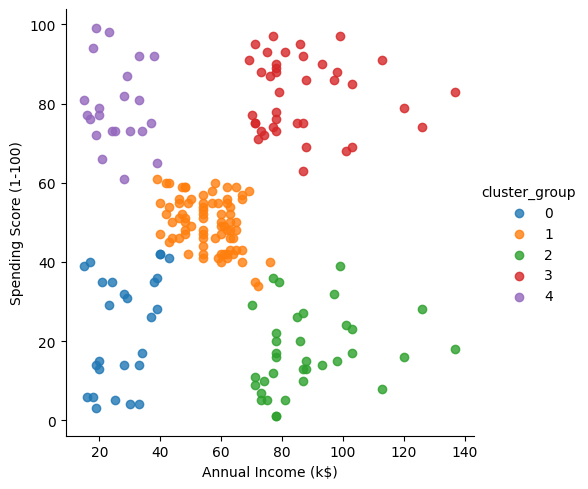

In [31]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5], 
                   fit_reg=False, legend=True)

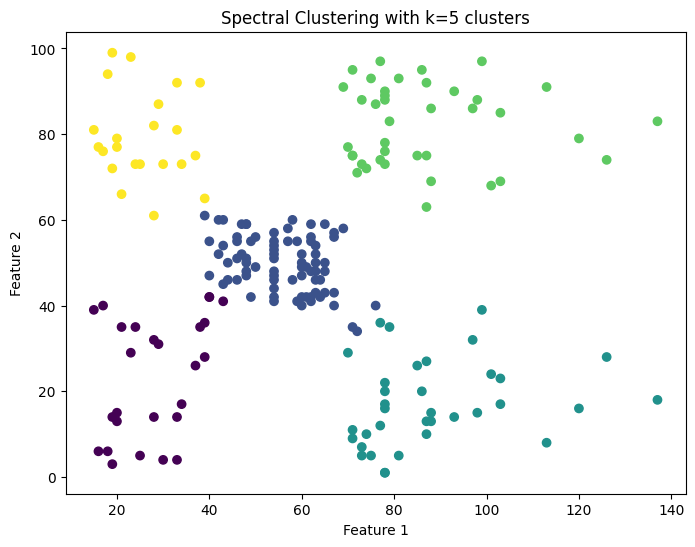

In [28]:
# 5. Visualize the results
#plt.figure(figsize=(8, 6))
#plt.scatter(x[:, 0], x[:, 1], c=y_pred, cmap='viridis')
#plt.title(f'Spectral Clustering with k={optimal_k} clusters')
#plt.xlabel('Feature 1')
#plt.ylabel('Feature 2')
#plt.show()